## Analyst Project

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib
from matplotlib.pyplot import figure
plt.style.use('ggplot')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12,8)

In [2]:
movies=pd.read_csv("movies.csv")
movies

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [3]:
movies.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7668 non-null   object 
 9   star      7668 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [5]:
movies.isna().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         0
star           0
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [6]:
##Or
for col in movies.columns:
    pct_missing = np.mean(movies[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [7]:
movies.shape

(7668, 15)

In [8]:
movies['gross'] = movies['gross'].fillna(0)
movies['budget'] = movies['budget'].fillna(0)

In [9]:
movies['budget'] = movies['budget'].astype('int64')
movies['gross'] = movies['gross'].astype('int64')

In [10]:
movies['rating'].fillna(movies['rating'].mode()[0],inplace=True)
movies['score'].fillna(movies['score'].mode()[0],inplace=True)
movies['votes'].fillna(movies['votes'].mode()[0],inplace=True)
movies['country'].fillna(movies['country'].mode()[0],inplace=True)
movies['company'].fillna(movies['company'].mode()[0],inplace=True)
movies['runtime'].fillna(movies['runtime'].median(),inplace=True)
movies['released'].fillna(movies['released'].mode()[0],inplace=True)

In [11]:
movies.isna().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [12]:
movies.sort_values(by=['gross'],inplace=False,ascending=False).head(10)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0
7480,The Lion King,PG,Animation,2019,"July 19, 2019 (United States)",6.9,222000.0,Jon Favreau,Jeff Nathanson,Donald Glover,United States,260000000,1670727580,Walt Disney Pictures,118.0
6653,Jurassic World,PG-13,Action,2015,"June 12, 2015 (United States)",7.0,593000.0,Colin Trevorrow,Rick Jaffa,Chris Pratt,United States,150000000,1670516444,Universal Pictures,124.0
6043,The Avengers,PG-13,Action,2012,"May 4, 2012 (United States)",8.0,1300000.0,Joss Whedon,Joss Whedon,Robert Downey Jr.,United States,220000000,1518815515,Marvel Studios,143.0
6646,Furious 7,PG-13,Action,2015,"April 3, 2015 (United States)",7.1,370000.0,James Wan,Chris Morgan,Vin Diesel,United States,190000000,1515341399,Universal Pictures,137.0
7494,Frozen II,PG,Animation,2019,"November 22, 2019 (United States)",6.8,148000.0,Chris Buck,Jennifer Lee,Kristen Bell,United States,150000000,1450026933,Walt Disney Animation Studios,103.0


In [59]:
pd.set_option('display.max_rows',None)

In [13]:
## Drop any duplicates
movies['company'].drop_duplicates().sort_values(ascending=False)

7129                                thefyzz
5664                            micro_scope
6412               iDeal Partners Film Fund
4007                               i5 Films
6793                             i am OTHER
                       ...                 
5813                        10 West Studios
3748                     1+2 Seisaku Iinkai
3024                        .406 Production
7525    "Weathering With You" Film Partners
4345        "DIA" Productions GmbH & Co. KG
Name: company, Length: 2385, dtype: object

In [14]:
movies

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,R,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,Universal Pictures,90.0
7664,Dream Round,R,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,0,0,Cactus Blue Entertainment,90.0
7665,Saving Mbango,R,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,0,Embi Productions,104.0
7666,It's Just Us,R,Drama,2020,"October 1, 2020 (United States)",6.6,13000.0,James Randall,James Randall,Christina Roz,United States,15000,0,Universal Pictures,120.0


In [15]:
##Budget high Correlation
##Company high Correlation

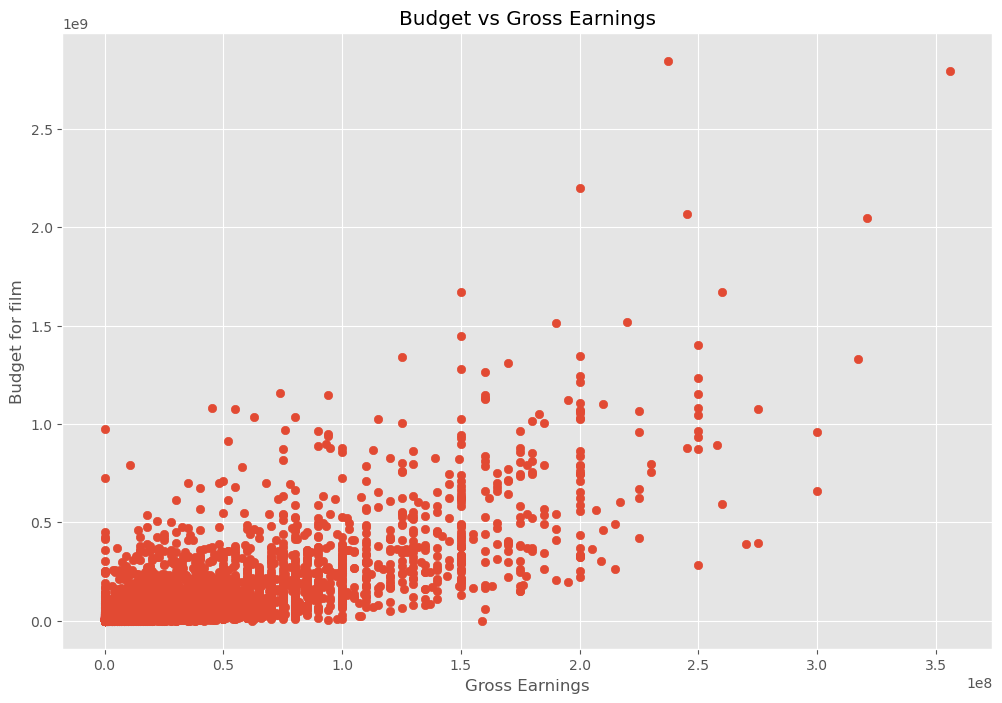

In [18]:
#Budget vs Gross Scatter plot
plt.scatter(x=movies['budget'],y=movies['gross']);
plt.title('Budget vs Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Budget for film')
plt.show()

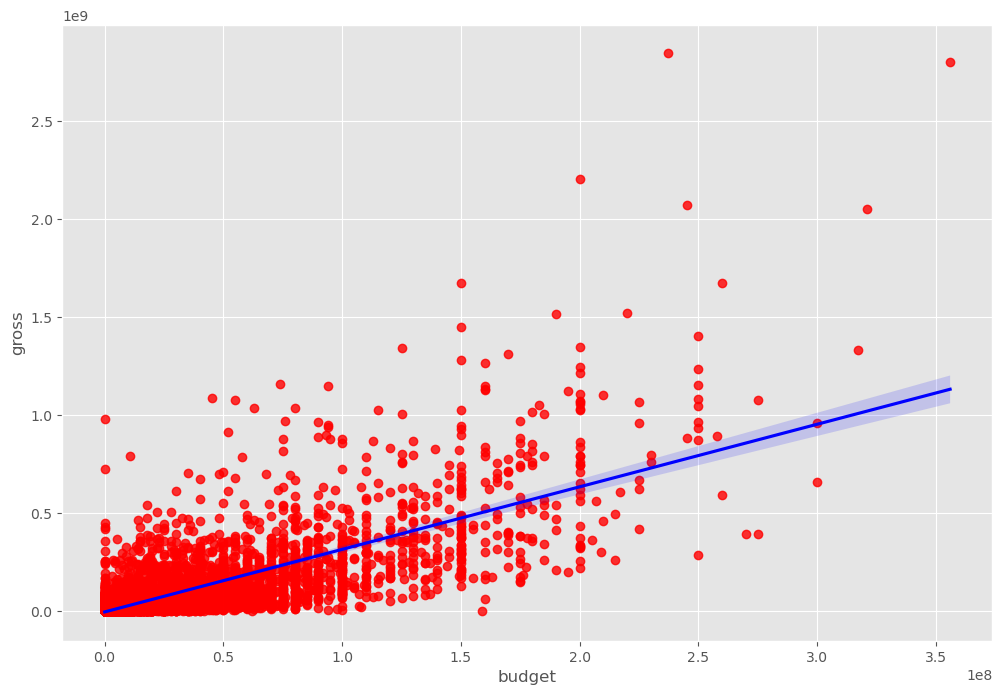

In [23]:
## Regression plot(Budget vs gross)
sns.regplot(x='budget',y='gross',data=movies,scatter_kws={"color":"red"},line_kws={"color":"blue"});

In [26]:
##Lets start looking at correlation
movies.corr()

C:\Users\joshu\AppData\Local\Temp\ipykernel_20412\1265148815.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  movies.corr()


,year,score,votes,budget,gross,runtime
year,1.000000,0.098084,0.222485,0.309212,0.261900,0.120662
score,0.098084,1.000000,0.409123,0.055605,0.186343,0.399411
votes,0.222485,0.409123,1.000000,0.486918,0.632865,0.309137
budget,0.309212,0.055605,0.486918,1.000000,0.750157,0.269519
gross,0.261900,0.186343,0.632865,0.750157,1.000000,0.245259
runtime,0.120662,0.399411,0.309137,0.269519,0.245259,1.000000


In [27]:
movies.corr(method='pearson')

C:\Users\joshu\AppData\Local\Temp\ipykernel_20412\2789189174.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  movies.corr(method='pearson')


,year,score,votes,budget,gross,runtime
year,1.000000,0.098084,0.222485,0.309212,0.261900,0.120662
score,0.098084,1.000000,0.409123,0.055605,0.186343,0.399411
votes,0.222485,0.409123,1.000000,0.486918,0.632865,0.309137
budget,0.309212,0.055605,0.486918,1.000000,0.750157,0.269519
gross,0.261900,0.186343,0.632865,0.750157,1.000000,0.245259
runtime,0.120662,0.399411,0.309137,0.269519,0.245259,1.000000


In [31]:
##movies.corr(method='kendall')

In [30]:
##movies.corr(method='spearman')

**Theres a high correlation between Budget and gross**

C:\Users\joshu\AppData\Local\Temp\ipykernel_20412\706878304.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix=movies.corr(method='pearson')


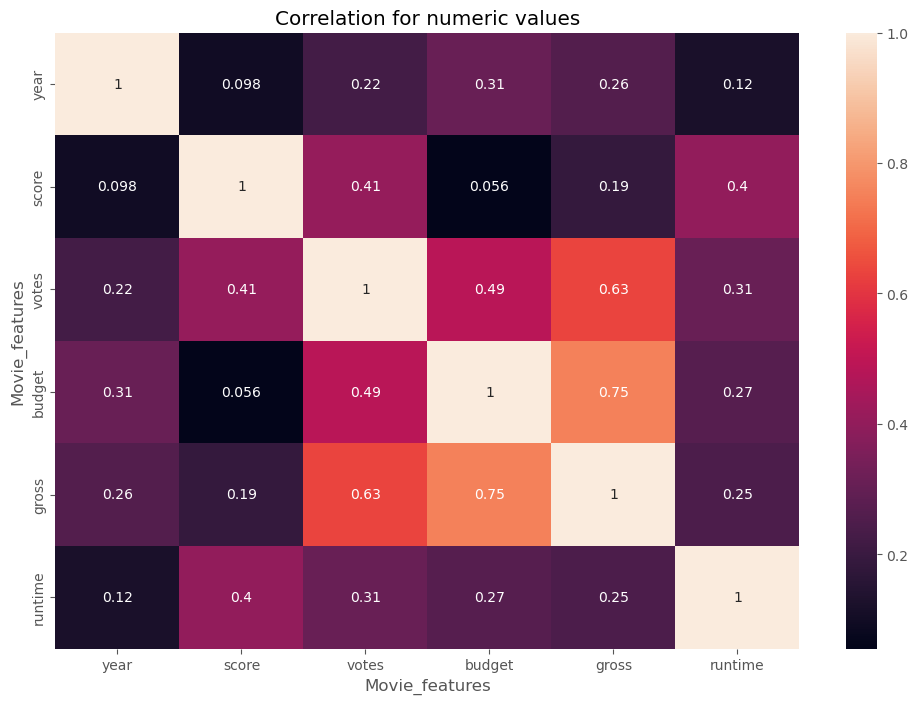

In [34]:
correlation_matrix=movies.corr(method='pearson')
sns.heatmap(correlation_matrix,annot=True)
plt.title('Correlation for numeric values')
plt.xlabel('Movie_features')
plt.ylabel('Movie_features')

plt.show()

In [38]:
df_numerized=movies

for column_name in df_numerized.columns:
    if(df_numerized[column_name].dtype=='object'):
        df_numerized[column_name]=df_numerized[column_name].astype('category')
        df_numerized[column_name]=df_numerized[column_name].cat.codes
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,6587,6,6,1980,1705,8.4,927000.0,2589,4014,1047,54,19000000,46998772,2319,146.0
1,5573,6,1,1980,1492,5.8,65000.0,2269,1632,327,55,4500000,58853106,731,104.0
2,5142,4,0,1980,1771,8.7,1200000.0,1111,2567,1745,55,18000000,538375067,1540,124.0
3,286,4,4,1980,1492,7.7,221000.0,1301,2000,2246,55,3500000,83453539,1812,88.0
4,1027,6,4,1980,1543,7.3,108000.0,1054,521,410,55,6000000,39846344,1777,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,3705,6,6,2020,2964,3.1,18.0,1500,2289,2421,55,7000,0,2281,90.0
7664,1678,6,4,2020,1107,4.7,36.0,774,2614,1886,55,0,0,539,90.0
7665,4717,6,6,2020,193,5.7,29.0,2061,2683,2040,55,58750,0,941,104.0
7666,2843,6,6,2020,2817,6.6,13000.0,1184,1824,450,55,15000,0,2281,120.0


In [39]:
movies

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,6587,6,6,1980,1705,8.4,927000.0,2589,4014,1047,54,19000000,46998772,2319,146.0
1,5573,6,1,1980,1492,5.8,65000.0,2269,1632,327,55,4500000,58853106,731,104.0
2,5142,4,0,1980,1771,8.7,1200000.0,1111,2567,1745,55,18000000,538375067,1540,124.0
3,286,4,4,1980,1492,7.7,221000.0,1301,2000,2246,55,3500000,83453539,1812,88.0
4,1027,6,4,1980,1543,7.3,108000.0,1054,521,410,55,6000000,39846344,1777,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,3705,6,6,2020,2964,3.1,18.0,1500,2289,2421,55,7000,0,2281,90.0
7664,1678,6,4,2020,1107,4.7,36.0,774,2614,1886,55,0,0,539,90.0
7665,4717,6,6,2020,193,5.7,29.0,2061,2683,2040,55,58750,0,941,104.0
7666,2843,6,6,2020,2817,6.6,13000.0,1184,1824,450,55,15000,0,2281,120.0


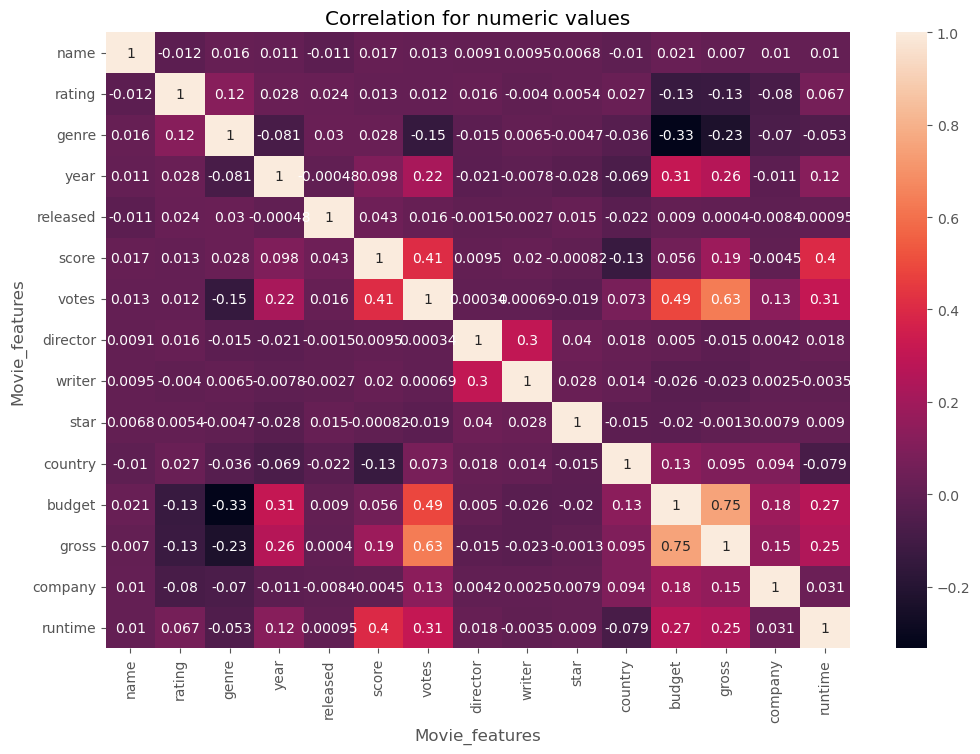

In [40]:
correlation_matrix=df_numerized.corr(method='pearson')
sns.heatmap(correlation_matrix,annot=True)
plt.title('Correlation for numeric values')
plt.xlabel('Movie_features')
plt.ylabel('Movie_features')

plt.show()

In [41]:
df_numerized.corr()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
name,1.000000,-0.012441,0.016355,0.011453,-0.011087,0.017114,0.013045,0.009079,0.009495,0.006840,-0.010425,0.020548,0.006989,0.010369,0.010335
rating,-0.012441,1.000000,0.123465,0.027931,0.023643,0.013304,0.012253,0.016255,-0.004042,0.005382,0.026930,-0.131148,-0.130522,-0.079626,0.066597
genre,0.016355,0.123465,1.000000,-0.081261,0.029997,0.027970,-0.145294,-0.015258,0.006467,-0.004658,-0.035896,-0.334021,-0.234297,-0.070013,-0.052719
year,0.011453,0.027931,-0.081261,1.000000,-0.000484,0.098084,0.222485,-0.020795,-0.007780,-0.027901,-0.069423,0.309212,0.261900,-0.011438,0.120662
released,-0.011087,0.023643,0.029997,-0.000484,1.000000,0.042703,0.015930,-0.001492,-0.002699,0.015469,-0.022042,0.008986,0.000404,-0.008443,0.000947
score,0.017114,0.013304,0.027970,0.098084,0.042703,1.000000,0.409123,0.009522,0.019605,-0.000822,-0.134538,0.055605,0.186343,-0.004547,0.399411
votes,0.013045,0.012253,-0.145294,0.222485,0.015930,0.409123,1.000000,0.000336,0.000688,-0.019396,0.073500,0.486918,0.632865,0.130533,0.309137
director,0.009079,0.016255,-0.015258,-0.020795,-0.001492,0.009522,0.000336,1.000000,0.299820,0.039867,0.017926,0.004976,-0.014916,0.004250,0.017611
writer,0.009495,-0.004042,0.006467,-0.007780,-0.002699,0.019605,0.000688,0.299820,1.000000,0.028238,0.014326,-0.026473,-0.022781,0.002458,-0.003483
star,0.006840,0.005382,-0.004658,-0.027901,0.015469,-0.000822,-0.019396,0.039867,0.028238,1.000000,-0.015051,-0.020225,-0.001325,0.007936,0.008958


In [45]:
correlation_mat=df_numerized.corr()

corr_pairs=correlation_mat.unstack()

corr_pairs

name     name        1.000000
         rating     -0.012441
         genre       0.016355
         year        0.011453
         released   -0.011087
                       ...   
runtime  country    -0.079305
         budget      0.269519
         gross       0.245259
         company     0.030999
         runtime     1.000000
Length: 225, dtype: float64

In [46]:
sorted_pairs=corr_pairs.sort_values()
sorted_pairs

budget   genre     -0.334021
genre    budget    -0.334021
         gross     -0.234297
gross    genre     -0.234297
genre    votes     -0.145294
                      ...   
year     year       1.000000
genre    genre      1.000000
rating   rating     1.000000
company  company    1.000000
runtime  runtime    1.000000
Length: 225, dtype: float64

In [47]:
high_corr=sorted_pairs[(sorted_pairs)>0.5]
high_corr

gross     votes       0.632865
votes     gross       0.632865
gross     budget      0.750157
budget    gross       0.750157
name      name        1.000000
director  director    1.000000
gross     gross       1.000000
budget    budget      1.000000
country   country     1.000000
star      star        1.000000
writer    writer      1.000000
votes     votes       1.000000
score     score       1.000000
released  released    1.000000
year      year        1.000000
genre     genre       1.000000
rating    rating      1.000000
company   company     1.000000
runtime   runtime     1.000000
dtype: float64

## Votes and Budget have the highest correlations to gross earnings